# 07b — Surprise and DTW on ES, NQ, ZN and YM: The Multi-Market Event Book with the E-mini Dow

> **07b = Notebook 07 with YM (E-mini Dow) added.** Code, parameters and years are identical to Notebook 07; the only
> changes are the market list (ES, NQ, ZN **and YM**), a portfolio of the three equity indices (ES + NQ + YM) next to
> the ES + NQ one, and output names `nb07b_*`, so nothing from Notebook 07 is overwritten. YM prices come from
> `futures_1min_clean_v3_YM.parquet` (team repo, `combined/cleaning.py`). The portfolio of all markets is labelled
> "4-market". **Text cells below are copied from Notebook 07**: where they say "three markets" they describe Notebook 07.

# 07 — Surprise and DTW on ES, NQ and ZN: A Multi-Market Event Book

## Purpose

Notebooks 04–06 traded **ES only**. The supervisor asked us to apply the same signals to two more futures markets:

| Market | Contract | Why it should react to macro surprises |
|---|---|---|
| **ES** | E-mini S&P 500 | Equities: growth and discount-rate news |
| **NQ** | E-mini Nasdaq-100 | Tech-heavy equities, usually **more** rate-sensitive than ES |
| **ZN** | 10-year US Treasury note | Bonds: the **most direct** channel for inflation and policy surprises (yields move, prices move the other way) |

**Questions:**
1. Does the surprise strategy (Notebook 05) work on NQ and ZN, after each market's own costs?
2. Does DTW (Notebook 06) help on any of them?
3. Does a **three-market portfolio** raise the trade count and the Sharpe through diversification?

**Credits:** the NQ and ZN 1-minute data were pulled and cleaned by **Jack Duncan** (`blackrock-intraday/combined/cleaning.py`), and the contract specifications come from his `combined/config.py`. His multi-asset DTW book (ES, NQ, ZN) is the peer benchmark for this notebook.

## Methodology: fixed before looking at results

- **The same pipeline as Notebooks 05–06, run separately for each market:** entry at the close of the first post-release bar (T+1), exit 30 minutes after the release, walk-forward evaluation over 2019–2026, with 2016–2018 as history.
- **Each market has its own impact screen and its own signs.** Markets react to different releases, and in different directions: a strong payrolls print usually pushes **ES and NQ up** but **ZN down** (yields rise). The signs are estimated from each market's own jump reaction, on history only.
- **Costs are in each market's own ticks:** 2 ticks round trip plus $4.50 per contract. One ZN tick is large relative to its moves, so costs matter most there.

| Market | Tick | $ per point | $ per tick | ≈ 2-tick round trip |
|---|---|---|---|---|
| ES | 0.25 | 50 | 12.50 | ~1.4 bps |
| NQ | 0.25 | 20 | 5.00 | ~0.5–1 bps |
| ZN | 1/64 | 1,000 | 15.63 | ~2.8 bps |

- **Strategies per market:** CPI surprise model; multi-release naive surprise ("All · naive"); DTW only; surprise + DTW agreement (all releases and CPI).
- **Portfolio:** the markets are combined at **equal risk**, with weights from 2016–2018 history only (inverse volatility of each market's 30-minute release-window return).
- **Data:** ES uses this project's file, so ES reproduces Notebook 05 exactly (checked below). NQ and ZN use Jack's cleaned files from the team repo.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys, importlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# team repo (Jack Duncan's cleaned NQ and ZN files) sits next to this project
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
BBG_FILE = RAW_DIR / "Bloomberg Economic Releases.xlsx"
MARKETS = {
    "ES": (RAW_DIR / "ES_1m_2010_2026_full.parquet", "project"),
    "NQ": (TEAM_DATA / "futures_1min_clean_v3_NQ.parquet", "team_v3"),
    "ZN": (TEAM_DATA / "futures_1min_clean_v3_ZN.parquet", "team_v3"),
    "YM": (TEAM_DATA / "futures_1min_clean_v3_YM.parquet", "team_v3"),   # E-mini Dow (combined/cleaning.py)
}
EQUITIES = ["ES", "NQ", "YM"]
NB05_LOG = RESULTS_DIR / "nb05_trade_log.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
import src.surprise_universe as su
import src.dtw_signal as ds
import src.multi_asset as ma
for m in (sc, wf, su, ds, ma):
    importlib.reload(m)

for sym, (f, kind) in MARKETS.items():
    print(f"{sym}: {f}  exists: {f.exists()}")
print("Bloomberg:", BBG_FILE.exists(), "| NB05 trade log:", NB05_LOG.exists())

ES: /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/raw/ES_1m_2010_2026_full.parquet  exists: True
NQ: /Users/reza/Desktop/mfe-term_3/blackrock-intraday/data/processed/futures_1min_clean_v3_NQ.parquet  exists: True
ZN: /Users/reza/Desktop/mfe-term_3/blackrock-intraday/data/processed/futures_1min_clean_v3_ZN.parquet  exists: True
YM: /Users/reza/Desktop/mfe-term_3/blackrock-intraday/data/processed/futures_1min_clean_v3_YM.parquet  exists: True
Bloomberg: True | NB05 trade log: True


### 1.1 Pre-registered parameters

In [2]:
HIST_START = "2016-01-01"
EVAL_START, EVAL_END = "2019-01-01", "2026-06-30"
EVAL_YEARS = list(range(2019, 2027))
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25
K_FAMILIES, MIN_TRAIN, THRESHOLD = 10, 24, 1.0
TICKS_RT, COMMISSION_RT = 2.0, 4.5
N_NULL, N_BOOT = 1000, 5000
STRATS = ["CPI · surprise model", "All · naive", "All · DTW only", "All · surprise + DTW agree", "CPI · surprise + DTW agree"]

## 2. Releases, Families and Surprises (as in Notebook 05)

In [3]:
rows = su.load_bloomberg(BBG_FILE)
fam = su.build_families(rows)
surp = su.standardise_surprises(rows)
surp = surp[surp["ticker"].isin(fam["ticker"])]
print(f"Release rows: {len(rows):,} | families: {fam['family'].nunique()} | surprises with a z-score: {surp['z'].notna().sum():,}")

Release rows: 27,137 | families: 75 | surprises with a z-score: 17,328


## 3. Run the Full Pipeline for Each Market

Each market is loaded, roll-adjusted, screened, signed and traded independently. This takes about 1–3 minutes per market.

In [4]:
results, adj_by = {}, {}
for sym, (path, kind) in MARKETS.items():
    t0 = time.time()
    bars = ma.load_bars(path, kind)
    adj_by[sym] = ma.adjusted(bars)
    results[sym] = ma.run_market(sym, adj_by[sym], rows, fam, surp, hist_start=HIST_START,
                                 eval_start=EVAL_START, eval_end=EVAL_END, eval_years=EVAL_YEARS,
                                 k_families=K_FAMILIES, min_train=MIN_TRAIN, threshold=THRESHOLD,
                                 ticks_rt=TICKS_RT, commission_rt=COMMISSION_RT)
    print(f"   {sym} bars: {len(bars):,} ({bars.index.min().date()} to {bars.index.max().date()}) | {time.time()-t0:.0f}s")

cov = pd.DataFrame({sym: r["px"].assign(y=r["px"]["ts_utc"].dt.year).groupby("y")["w1"].apply(lambda v: v.notna().mean())
                    for sym, r in results.items()})
print("\nShare of release timestamps with a complete 30-minute trade window, by year:")
display(cov.round(3).T)

ES: 6,097 release timestamps, 5,920 with a trade return, avg cost 1.57 bps, DTW for 5,181 releases
   ES bars: 4,811,336 (2010-07-01 to 2026-06-30) | 6s
NQ: 6,097 release timestamps, 5,852 with a trade return, avg cost 0.61 bps, DTW for 5,229 releases
   NQ bars: 5,255,764 (2010-07-01 to 2026-06-30) | 6s
ZN: 6,097 release timestamps, 5,878 with a trade return, avg cost 2.93 bps, DTW for 5,244 releases
   ZN bars: 5,392,031 (2010-07-01 to 2026-06-30) | 6s
YM: 6,097 release timestamps, 5,708 with a trade return, avg cost 0.95 bps, DTW for 5,232 releases
   YM bars: 5,195,343 (2010-07-01 to 2026-06-30) | 6s

Share of release timestamps with a complete 30-minute trade window, by year:


y,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
ES,0.971,0.965,0.966,0.964,0.961,0.988,0.983,0.986,0.984,0.993,0.892
NQ,0.922,0.940,0.958,0.969,0.968,0.997,0.983,0.971,0.963,0.979,0.887
ZN,0.950,0.952,0.961,0.971,0.961,0.972,0.994,0.977,0.982,0.973,0.887
YM,0.927,0.935,0.971,0.891,0.952,0.984,0.983,0.941,0.920,0.921,0.834


### 3.1 Validation: ES must reproduce Notebook 05

In [5]:
log5 = pd.read_csv(NB05_LOG)
log5["timestamp_utc"] = pd.to_datetime(log5["timestamp_utc"], utc=True)
for s in ["All · naive", "CPI · surprise model"]:
    a = log5[log5["strategy"] == s].set_index("timestamp_utc")["net_bps"]
    b = results["ES"]["trades"][s].set_index("timestamp_utc")["net_bps"]
    j = pd.concat([a, b], axis=1, keys=["nb05", "nb07"]).dropna()
    print(f"{s:<24s} common releases {len(j)} / NB05 {len(a)} | max |diff| = {(j.nb05 - j.nb07).abs().max():.2e} bps")
    assert (j.nb05 - j.nb07).abs().max() < 1e-6, "ES does not reproduce Notebook 05"
print("PASSED: ES reproduces Notebook 05 exactly")

All · naive              common releases 809 / NB05 809 | max |diff| = 1.42e-14 bps
CPI · surprise model     common releases 89 / NB05 89 | max |diff| = 3.55e-15 bps
PASSED: ES reproduces Notebook 05 exactly


### 3.2 Do the markets react to CPI in the expected directions?

In [6]:
cpi_ts = surp[surp["ticker"] == "CPI CHNG Index"][["ts_utc", "z"]].dropna()
cpi_ts = cpi_ts[(cpi_ts["ts_utc"] >= pd.Timestamp(EVAL_START, tz="UTC"))]
jumps = pd.DataFrame({sym: cpi_ts["ts_utc"].map(r["px"].set_index("ts_utc")["jump"]).to_numpy()
                      for sym, r in results.items()}, index=cpi_ts["ts_utc"])
jumps["CPI MoM surprise z"] = cpi_ts["z"].to_numpy()
print("Correlation of the instant jump with the CPI MoM surprise, and across markets (2019-2026):")
display(jumps.corr().round(2))

sign_tab = pd.DataFrame({sym: r["signs"][EVAL_YEARS[0]] for sym, r in results.items()})
key = {"CPI CHNG Index": "CPI MoM", "CPUPXCHG Index": "Core CPI MoM", "NFP TCH Index": "Nonfarm payrolls",
       "USURTOT Index": "Unemployment rate", "RSTAMOM Index": "Retail sales", "NAPMPMI Index": "ISM Manufacturing"}
print("Line signs estimated on 2016-2018 (+1: a positive surprise pushed the price up):")
display(sign_tab.reindex(list(key)).rename(index=key))

Correlation of the instant jump with the CPI MoM surprise, and across markets (2019-2026):


,ES,NQ,ZN,YM,CPI MoM surprise z
ES,1.000,0.980,0.870,0.990,-0.580
NQ,0.980,1.000,0.860,0.960,-0.600
ZN,0.870,0.860,1.000,0.860,-0.600
YM,0.990,0.960,0.860,1.000,-0.560
CPI MoM surprise z,-0.580,-0.600,-0.600,-0.560,1.000


Line signs estimated on 2016-2018 (+1: a positive surprise pushed the price up):


,ES,NQ,ZN,YM
CPI MoM,-1.000,-1.000,-1.000,-1.000
Core CPI MoM,-1.000,-1.000,-1.000,-1.000
Nonfarm payrolls,1.000,1.000,-1.000,1.000
Unemployment rate,1.000,1.000,-1.000,1.000
Retail sales,1.000,1.000,-1.000,1.000
ISM Manufacturing,1.000,1.000,-1.000,1.000


**Expected pattern.** A hot CPI print should push **all three markets down**: stocks fall and bond prices fall as yields rise. A strong payrolls print should push **ES and NQ up** but **ZN down**. If the signs look like this, each market's signal is set up correctly.

## 4. Which Releases Does Each Market React To?

In [7]:
adm = {}
for sym, r in results.items():
    ranks = pd.DataFrame({y: r["screens"][y].set_index("family")["rank"] for y in EVAL_YEARS})
    adm[sym] = ranks[(ranks <= K_FAMILIES).any(axis=1)].sort_values(EVAL_YEARS[-1])
    print(f"\n=== {sym}: families admitted (top {K_FAMILIES}) in at least one year — rank by year ===")
    display(adm[sym].astype("Int64"))


=== ES: families admitted (top 10) in at least one year — rank by year ===


,2019,2020,2021,2022,2023,2024,2025,2026
family,,,,,,,,
CPI,2,4,5,3,1,1,1,1
Employment Report (NFP),1,1,1,1,4,3,3,2
Fed Interest on Reserve Balances Rate,<NA>,<NA>,<NA>,<NA>,2,2,2,3
FOMC Rate Decision,<NA>,2,2,2,3,4,4,4
ISM Manufacturing,8,6,12,13,5,8,6,5
U. of Michigan Sentiment,22,25,22,16,7,6,7,6
ISM Services,5,7,7,7,6,5,5,7
JOLTS,13,15,8,9,11,7,8,8
Dallas Fed Manf. Activity,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,9



=== NQ: families admitted (top 10) in at least one year — rank by year ===


,2019,2020,2021,2022,2023,2024,2025,2026
family,,,,,,,,
CPI,<NA>,3,2,1,1,1,1,1
Employment Report (NFP),1,1,1,2,4,3,3,2
Fed Interest on Reserve Balances Rate,<NA>,<NA>,<NA>,<NA>,2,2,2,3
FOMC Rate Decision,<NA>,<NA>,3,3,3,4,4,4
Dallas Fed Manf. Activity,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5
ISM Services,5,8,7,9,5,5,5,6
ISM Manufacturing,4,5,11,14,8,9,6,7
U. of Michigan Sentiment,24,29,20,15,7,6,7,8
PPI,14,19,9,8,13,12,10,9



=== ZN: families admitted (top 10) in at least one year — rank by year ===


,2019,2020,2021,2022,2023,2024,2025,2026
family,,,,,,,,
FOMC Rate Decision,<NA>,1,1,1,1,1,1,1
ISM Services Prices Paid,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2
Employment Report (NFP),1,2,2,2,3,3,3,3
CPI,3,6,6,5,2,2,2,4
Fed Interest on Reserve Balances Rate,<NA>,<NA>,<NA>,<NA>,5,4,4,5
ISM Services,4,5,5,4,6,6,5,6
ISM New Orders,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,7
ISM Manufacturing,<NA>,3,3,3,4,5,6,8
S&P Global US Manufacturing PMI,10,8,8,8,8,7,7,9



=== YM: families admitted (top 10) in at least one year — rank by year ===


,2019,2020,2021,2022,2023,2024,2025,2026
family,,,,,,,,
CPI,<NA>,5,8,5,1,1,1,1
Employment Report (NFP),1,1,1,1,3,2,2,2
Fed Interest on Reserve Balances Rate,<NA>,<NA>,<NA>,<NA>,2,3,3,3
FOMC Rate Decision,<NA>,<NA>,2,2,4,4,4,4
ISM Manufacturing,3,3,5,6,5,5,5,5
U. of Michigan Sentiment,18,22,24,20,7,7,7,6
ISM Services,4,8,10,8,8,8,6,7
JOLTS,8,14,9,10,12,6,9,8
PPI,<NA>,15,6,9,9,10,11,9


## 5. Performance by Market (2019–2026, net of costs)

In [8]:
def sharpe_m(tr, a, b, drop_year=None):
    m = wf.monthly_returns(tr, a, b)
    if drop_year:
        m = m[m.index.year != drop_year]
    sd = m.std(ddof=1)
    return m.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

rows_p = []
for sym, r in results.items():
    for s in STRATS:
        t = r["trades"][s]
        p = wf.performance(t, EVAL_START, EVAL_END, s)
        _, p_null = su.random_sign_pvalue(t, wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
        rows_p.append(dict(market=sym, strategy=s, trades_per_year=p["trades"] / N_YEARS, hit_rate=p["hit_rate"],
                           avg_cost_bps=p["avg_cost_bps"], avg_net_bps=p["avg_net_bps"], total_net_pct=p["total_net_pct"],
                           sharpe_gross=p["sharpe_gross"], sharpe_net=p["sharpe_net"],
                           sharpe_2019_21=sharpe_m(t, "2019-01-01", "2021-12-31"),
                           sharpe_2022_26=sharpe_m(t, "2022-01-01", EVAL_END),
                           sharpe_ex_2022=sharpe_m(t, EVAL_START, EVAL_END, 2022),
                           max_dd_pct=p["max_dd_pct"], p_random_sign=p_null))
perf = pd.DataFrame(rows_p).set_index(["market", "strategy"])
perf.to_csv(RESULTS_DIR / "nb07b_performance_by_market.csv")
display(perf.round(3))

trades_per_year  hit_rate  avg_cost_bps  avg_net_bps  total_net_pct  sharpe_gross  sharpe_net  sharpe_2019_21  sharpe_2022_26  sharpe_ex_2022  max_dd_pct  \
market strategy                                                                                                                                                                                
ES     CPI · surprise model                  8.941     0.582         1.377        8.228          5.513         0.878       0.756           0.630           0.831           0.049      -2.035   
       All · naive                          98.352     0.507         1.412        1.736         12.793         1.170       0.647           0.321           0.833           0.275      -4.836   
       All · DTW only                       64.589     0.469         1.412       -1.454         -7.036        -0.011      -0.389           0.114          -0.626          -0.322     -11.004   
       All · surprise + DTW agree           52.579     0.510         1.422        1.138          4.484         0.698       0.313           0.536           0.203           0.067      -4.612   
       CPI · surprise + DTW agree            6.539     0.612         1.390       12.504          6.127         1.023       0.929           0.829           1.023           0.210      -1.169   
NQ     CPI · surprise model                 11.477     0.535         0.548        7.120          6.123         0.597       0.554           0.777           0.488          -0.014      -2.743   
       All · naive                          96.751     0.530         0.546        2.412         17.484         0.872       0.712           0.352           0.905           0.439      -5.662   
       All · DTW only                       63.121     0.503         0.541        0.345          1.631         0.212       0.083           0.916          -0.314           0.171      -8.282   
       All · surprise + DTW agree           50.844     0.535         0.547        3.107         11.838         0.729       0.621           0.613           0.634           0.588      -6.716   
       CPI · surprise + DTW agree            7.206     0.537         0.536       10.055          5.430         0.569       0.540           0.762           0.549          -0.051      -2.382   
ZN     CPI · surprise model                  0.133     0.000         3.171      -17.033         -0.170        -0.365      -0.365             NaN          -0.471          -0.392      -0.170   
       All · naive                          81.938     0.362         2.931       -3.346        -20.543        -0.298      -2.422          -3.359          -2.174          -2.534     -20.564   
       All · DTW only                       55.114     0.414         2.972       -2.154         -8.895         0.473      -1.250          -2.648          -0.917          -1.707      -9.150   
       All · surprise + DTW agree           41.770     0.374         2.947       -3.180         -9.954        -0.116      -1.568          -2.960          -1.222          -1.893     -10.179   
       CPI · surprise + DTW agree            0.000       NaN           NaN          NaN          0.000         0.000       0.000             NaN             NaN             NaN       0.000   
YM     CPI · surprise model                  8.808     0.500         0.857        4.670          3.082         0.535       0.453           0.348           0.510          -0.153      -1.965   
       All · naive                          92.614     0.530         0.854        1.733         12.029         1.012       0.681           0.610           0.719           0.399      -4.542   
       All · DTW only                       61.120     0.535         0.861        1.268          5.805         0.791       0.472           0.598           0.395           0.579      -4.015   
       All · surprise + DTW agree           49.376     0.549         0.856        2.943         10.889         1.207       0.936           1.108           0.838           0.943      -1.656   
   

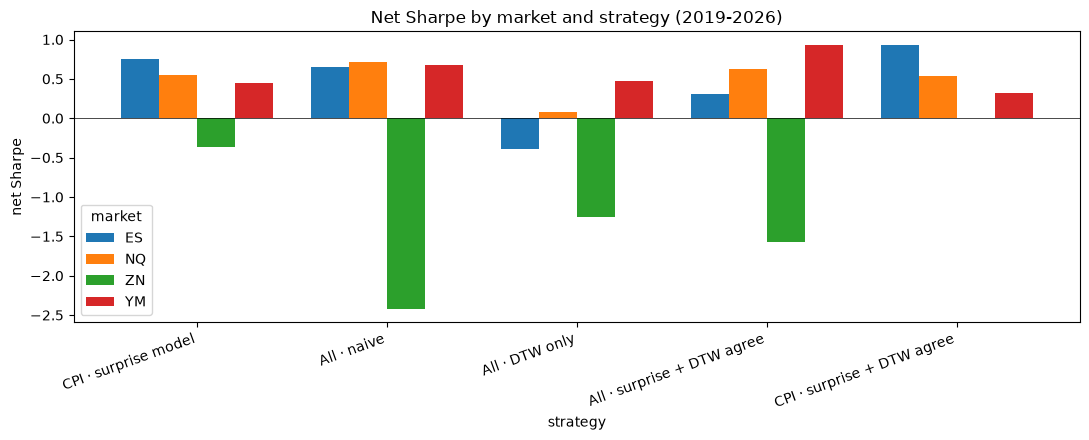

In [9]:
piv = perf["sharpe_net"].unstack("market")[list(MARKETS)].reindex(STRATS)
ax = piv.plot.bar(figsize=(11, 4.5), width=0.8)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("net Sharpe"); ax.set_title("Net Sharpe by market and strategy (2019-2026)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb07b_sharpe_by_market.png", dpi=150); plt.show()

**How to read it.** `sharpe_gross` against `sharpe_net` shows how much each market loses to costs; ZN is expected to lose the most. `p_random_sign` below 0.05 means the direction is genuinely informative in that market.

### 5.1 Which releases earn money in each market? (All · naive)

In [10]:
fam_rows = []
for sym, r in results.items():
    p = su.build_positions(r["panel"][r["panel"]["admitted"]], r["hist"], "naive", "w1", MIN_TRAIN, THRESHOLD)
    f = su.per_family_stats(p, "w1")
    f["market"] = sym
    fam_rows.append(f.reset_index())
fam_tab = pd.concat(fam_rows)
fam_tab.to_csv(RESULTS_DIR / "nb07b_per_family_by_market.csv", index=False)
display(fam_tab.pivot_table(index="family", columns="market", values="total_net_pct").round(2)
        .sort_values("ES", ascending=False))

market,ES,NQ,YM,ZN
family,,,,
CPI,4.330,6.040,3.760,-2.990
JOLTS,3.000,NaN,2.290,-0.540
Retail Sales,2.290,2.560,1.700,-4.460
U. of Michigan Sentiment,1.420,4.240,0.270,-1.830
Advance Goods Trade Balance,1.320,1.380,NaN,NaN
ISM Manufacturing,0.890,1.370,3.320,-2.030
Factory Orders,0.870,4.620,NaN,-1.040
Trade Balance,0.710,0.360,1.230,-0.620
Dallas Fed Manf. Activity,0.690,-1.210,NaN,NaN


### 5.2 Transaction costs by market

In [11]:
cost_rows = []
for sym, r in results.items():
    for ticks in [0, 1, 2, 4]:
        for s, t in ma.with_costs(r, ticks, COMMISSION_RT, MIN_TRAIN, THRESHOLD).items():
            pf = wf.performance(t, EVAL_START, EVAL_END, s)
            cost_rows.append(dict(market=sym, strategy=s, ticks_rt=ticks, sharpe_net=pf["sharpe_net"], avg_net_bps=pf["avg_net_bps"]))
cost_tab = pd.DataFrame(cost_rows)
cost_tab.to_csv(RESULTS_DIR / "nb07b_cost_sensitivity.csv", index=False)
display(cost_tab.pivot_table(index="ticks_rt", columns=["strategy", "market"], values="sharpe_net").round(2))

strategy All · naive                    CPI · surprise model                   
market            ES    NQ    YM     ZN                   ES    NQ    YM     ZN
ticks_rt                                                                       
0              1.090 0.820 0.910 -0.560                0.660 0.610 0.570  0.050
1              0.870 0.770 0.800 -1.490                0.600 0.590 0.490 -0.180
2              0.650 0.710 0.680 -2.420                0.760 0.550 0.450 -0.370
4              0.200 0.600 0.450 -4.240                0.610 0.540 0.590  0.000

## 6. Portfolios: All Markets, Equities (ES+NQ+YM) and ES+NQ

Each market's positions are scaled by an **equal-risk weight** (inverse volatility of its 30-minute release-window return over 2016–2018, ES = 1), then the markets are traded together.

In [12]:
weights = ma.risk_weights(results, HIST_START, EVAL_START)
print("Risk weights (contracts-equivalent per ES unit, history 2016-2018):")
display(weights.round(3).to_frame("weight"))

corr_tabs = {}
for s in ["All · naive", "CPI · surprise model"]:
    m = pd.DataFrame({sym: wf.monthly_returns(r["trades"][s], EVAL_START, EVAL_END) for sym, r in results.items()})
    corr_tabs[s] = m.corr()
    print(f"\nCorrelation of monthly net returns across markets — {s}:")
    display(corr_tabs[s].round(2))

PORT = {}
for s in STRATS:
    PORT[f"4-market · {s}"] = ma.portfolio(results, s, weights, f"4-market · {s}")
PORT["2-market (ES+NQ) · All · naive"] = ma.portfolio({k: results[k] for k in ["ES", "NQ"]}, "All · naive", weights, "2-market (ES+NQ) · All · naive")
PORT["2-market (ES+NQ) · CPI · surprise model"] = ma.portfolio({k: results[k] for k in ["ES", "NQ"]}, "CPI · surprise model", weights, "2-market (ES+NQ) · CPI · surprise model")
# the three equity indices together (YM added)
for s in ["All · naive", "CPI · surprise model"]:
    PORT[f"3-equity (ES+NQ+YM) · {s}"] = ma.portfolio({k: results[k] for k in EQUITIES}, s, weights, f"3-equity (ES+NQ+YM) · {s}")

rows_q = []
for name, t in PORT.items():
    p = wf.performance(t, EVAL_START, EVAL_END, name)
    _, p_null = su.random_sign_pvalue(t, wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    (lo, _, hi), _ = wf.bootstrap_sharpe(t, EVAL_START, EVAL_END, N_BOOT)
    rows_q.append(dict(portfolio=name, trades_per_year=p["trades"] / N_YEARS, avg_net_bps=p["avg_net_bps"],
                       total_net_pct=p["total_net_pct"], ann_return_pct=p["ann_return_pct"], ann_vol_pct=p["ann_vol_pct"],
                       sharpe_net=p["sharpe_net"], ci_5=lo, ci_95=hi,
                       sharpe_ex_2022=sharpe_m(t, EVAL_START, EVAL_END, 2022), max_dd_pct=p["max_dd_pct"], p_random_sign=p_null))
port_tab = pd.DataFrame(rows_q).set_index("portfolio")
port_tab.to_csv(RESULTS_DIR / "nb07b_portfolio.csv")
pd.concat(PORT.values()).to_csv(RESULTS_DIR / "nb07b_portfolio_trade_log.csv", index=False)
display(port_tab.round(3))

Risk weights (contracts-equivalent per ES unit, history 2016-2018):


,weight
ES,1.000
NQ,0.711
ZN,2.672
YM,1.022



Correlation of monthly net returns across markets — All · naive:


,ES,NQ,ZN,YM
ES,1.000,0.790,-0.130,0.660
NQ,0.790,1.000,-0.120,0.430
ZN,-0.130,-0.120,1.000,-0.010
YM,0.660,0.430,-0.010,1.000



Correlation of monthly net returns across markets — CPI · surprise model:


,ES,NQ,ZN,YM
ES,1.000,0.800,-0.020,0.860
NQ,0.800,1.000,-0.030,0.760
ZN,-0.020,-0.030,1.000,0.010
YM,0.860,0.760,0.010,1.000


,trades_per_year,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_net,ci_5,ci_95,sharpe_ex_2022,max_dd_pct,p_random_sign
portfolio,,,,,,,,,,,
4-market · CPI · surprise model,29.359,5.709,12.561,1.675,2.752,0.608,-0.125,1.349,-0.075,-5.789,0.018
4-market · All · naive,369.654,-0.627,-17.366,-2.315,6.804,-0.340,-1.077,0.399,-0.745,-23.446,0.000
4-market · All · DTW only,243.945,-1.297,-23.707,-3.161,4.969,-0.636,-1.279,-0.012,-0.623,-29.075,0.028
4-market · All · surprise + DTW agree,194.569,-0.176,-2.567,-0.342,5.053,-0.068,-0.742,0.605,-0.286,-15.649,0.001
4-market · CPI · surprise + DTW agree,19.484,8.169,11.926,1.590,2.375,0.670,-0.009,1.307,-0.010,-3.408,0.010
2-market (ES+NQ) · All · naive,195.102,1.725,25.226,3.364,4.702,0.715,-0.007,1.435,0.376,-7.417,0.000
2-market (ES+NQ) · CPI · surprise model,20.418,6.449,9.867,1.316,1.914,0.687,-0.013,1.387,0.017,-3.297,0.023
3-equity (ES+NQ+YM) · All · naive,287.716,1.740,37.516,5.002,6.411,0.780,0.099,1.497,0.427,-9.194,0.000
3-equity (ES+NQ+YM) · CPI · surprise model,29.225,5.943,13.016,1.735,2.750,0.631,-0.101,1.373,-0.043,-5.332,0.020


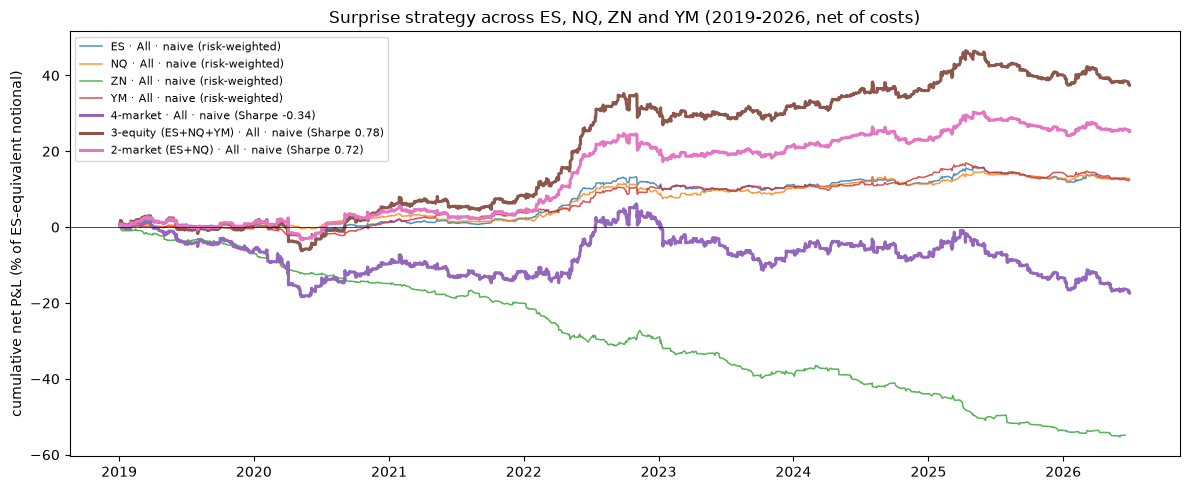

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
show = [(m, "All · naive") for m in MARKETS]
for sym, s in show:
    cum, _ = wf.drawdown_series(results[sym]["trades"][s], EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values * weights[sym], lw=1.1, alpha=0.8, label=f"{sym} · {s} (risk-weighted)")
for name in ["4-market · All · naive", "3-equity (ES+NQ+YM) · All · naive", "2-market (ES+NQ) · All · naive"]:
    cum, _ = wf.drawdown_series(PORT[name], EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values, lw=2.2, label=f"{name} (Sharpe {port_tab.loc[name, 'sharpe_net']:.2f})")
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("cumulative net P&L (% of ES-equivalent notional)")
ax.set_title("Surprise strategy across ES, NQ, ZN and YM (2019-2026, net of costs)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb07b_portfolio_cumulative.png", dpi=150); plt.show()

### 6.1 Peer-format metrics for the portfolios (daily, vs ES buy-and-hold)

In [14]:
daily_close = sc.build_daily_close(adj_by["ES"])
days = daily_close.index[(daily_close.index >= pd.Timestamp(EVAL_START)) & (daily_close.index <= pd.Timestamp(EVAL_END))]
bh = wf.buy_hold_daily(daily_close, days)
peer = pd.DataFrame({name: wf.peer_metrics(wf.daily_returns(t, days), bh, trades_per_year=port_tab.loc[name, "trades_per_year"])
                     for name, t in PORT.items()}).T
peer.to_csv(RESULTS_DIR / "nb07b_portfolio_peer_metrics.csv")
display(peer.round(3))

,total_pct,vol_pct,sharpe,max_dd_pct,beta,corr,trades_per_year
4-market · CPI · surprise model,12.561,2.817,0.611,-5.757,-0.003,-0.018,29.359
4-market · All · naive,-17.279,7.574,-0.313,-22.854,0.002,0.005,369.654
4-market · All · DTW only,-21.515,5.553,-0.531,-26.729,0.007,0.026,243.945
4-market · All · surprise + DTW agree,-2.303,5.461,-0.058,-15.158,0.004,0.016,194.569
4-market · CPI · surprise + DTW agree,11.926,2.438,0.671,-3.408,-0.004,-0.035,19.484
2-market (ES+NQ) · All · naive,25.464,4.655,0.750,-7.417,0.002,0.007,195.102
2-market (ES+NQ) · CPI · surprise model,9.867,1.967,0.688,-3.295,-0.002,-0.021,20.418
3-equity (ES+NQ+YM) · All · naive,37.753,6.660,0.777,-9.206,-0.003,-0.008,287.716
3-equity (ES+NQ+YM) · CPI · surprise model,13.016,2.818,0.633,-5.302,-0.002,-0.017,29.225


## 7. Final Comparison

In [15]:
rows_f = []
for sym in MARKETS:
    for s in ["CPI · surprise model", "All · naive", "All · surprise + DTW agree", "All · DTW only"]:
        r = perf.loc[(sym, s)]
        rows_f.append(dict(book=f"{sym} · {s}", trades_per_year=r.trades_per_year, net_bps_per_trade=r.avg_net_bps,
                           sharpe_net=r.sharpe_net, sharpe_ex_2022=r.sharpe_ex_2022, max_dd_pct=r.max_dd_pct,
                           p_random_sign=r.p_random_sign))
for name in PORT:
    r = port_tab.loc[name]
    rows_f.append(dict(book=name, trades_per_year=r.trades_per_year, net_bps_per_trade=r.avg_net_bps,
                       sharpe_net=r.sharpe_net, sharpe_ex_2022=r.sharpe_ex_2022, max_dd_pct=r.max_dd_pct,
                       p_random_sign=r.p_random_sign))
rows_f += [
    dict(book="Peer: Jack DTW, ES only (slide, 2018-26)", trades_per_year=185, net_bps_per_trade=1.18, sharpe_net=0.613, max_dd_pct=-4.928),
    dict(book="Peer: Jack DTW, ES/NQ/ZN combined (README test 2021-26, quarter tick)", sharpe_net=-0.19),
]
final = pd.DataFrame(rows_f).set_index("book")
final.to_csv(RESULTS_DIR / "nb07b_final_comparison.csv")
display(final.round(3))

,trades_per_year,net_bps_per_trade,sharpe_net,sharpe_ex_2022,max_dd_pct,p_random_sign
book,,,,,,
ES · CPI · surprise model,8.941,8.228,0.756,0.049,-2.035,0.006
ES · All · naive,98.352,1.736,0.647,0.275,-4.836,0.000
ES · All · surprise + DTW agree,52.579,1.138,0.313,0.067,-4.612,0.030
ES · All · DTW only,64.589,-1.454,-0.389,-0.322,-11.004,0.479
NQ · CPI · surprise model,11.477,7.120,0.554,-0.014,-2.743,0.047
NQ · All · naive,96.751,2.412,0.712,0.439,-5.662,0.005
NQ · All · surprise + DTW agree,50.844,3.107,0.621,0.588,-6.716,0.021
NQ · All · DTW only,63.121,0.345,0.083,0.171,-8.282,0.271
ZN · CPI · surprise model,0.133,-17.033,-0.365,-0.392,-0.170,1.000


### 7.1 Automatic summary

In [16]:
print("=" * 110)
print("NOTEBOOK 07b SUMMARY — surprise and DTW on ES, NQ, ZN, YM (2019-2026, net of costs)")
print("=" * 110)
for sym in MARKETS:
    print(f"\n{sym} ({ma.SPECS[sym]['name']}), median cost {results[sym]['px']['cost_bps'].median():.2f} bps:")
    for s in STRATS:
        r = perf.loc[(sym, s)]
        print(f"  {s:<30s} {r.trades_per_year:5.0f} tr/yr | {r.avg_net_bps:6.2f} bps | Sharpe gross {r.sharpe_gross:5.2f} "
              f"net {r.sharpe_net:5.2f} | ex-2022 {r.sharpe_ex_2022:5.2f} | random-sign p {r.p_random_sign:.3f}")
print("\nPortfolios (equal risk, weights " + ", ".join(f"{k} {v:.2f}" for k, v in weights.items()) + "):")
for name, r in port_tab.iterrows():
    print(f"  {name:<42s} {r.trades_per_year:5.0f} tr/yr | Sharpe {r.sharpe_net:5.2f} [{r.ci_5:.2f}, {r.ci_95:.2f}] | "
          f"ex-2022 {r.sharpe_ex_2022:5.2f} | maxDD {r.max_dd_pct:6.2f}% | random-sign p {r.p_random_sign:.3f}")

NOTEBOOK 07b SUMMARY — surprise and DTW on ES, NQ, ZN, YM (2019-2026, net of costs)

ES (E-mini S&P 500), median cost 1.57 bps:
  CPI · surprise model               9 tr/yr |   8.23 bps | Sharpe gross  0.88 net  0.76 | ex-2022  0.05 | random-sign p 0.006
  All · naive                       98 tr/yr |   1.74 bps | Sharpe gross  1.17 net  0.65 | ex-2022  0.28 | random-sign p 0.000
  All · DTW only                    65 tr/yr |  -1.45 bps | Sharpe gross -0.01 net -0.39 | ex-2022 -0.32 | random-sign p 0.479
  All · surprise + DTW agree        53 tr/yr |   1.14 bps | Sharpe gross  0.70 net  0.31 | ex-2022  0.07 | random-sign p 0.030
  CPI · surprise + DTW agree         7 tr/yr |  12.50 bps | Sharpe gross  1.02 net  0.93 | ex-2022  0.21 | random-sign p 0.000

NQ (E-mini Nasdaq-100), median cost 0.61 bps:
  CPI · surprise model              11 tr/yr |   7.12 bps | Sharpe gross  0.60 net  0.55 | ex-2022 -0.01 | random-sign p 0.047
  All · naive                       97 tr/yr |   2.41 bps | Sha

## 8. Interpretation and Conclusion (with YM)

### Purpose of Notebook 07b

Notebook 07 applied the surprise and DTW strategies to ES, NQ and ZN and combined them. Notebooks 02b–06b (YM) showed that the E-mini Dow behaves like ES. Notebook 07b runs the same pipeline, unchanged, on **four markets (ES, NQ, ZN, YM)** and asks:

> **Does the surprise strategy work on YM inside the common multi-market pipeline, and does adding YM to ES and NQ improve the equity portfolio?**

**Data check.** All four markets have 6,097 release timestamps since 2016; 94–97% have a complete 30-minute window (YM 5,708, ES 5,920, NQ 5,852, ZN 5,878). ES reproduces Notebook 05 exactly (max difference 1e-14 bps), and the YM rows reproduce Notebooks 05b–06b (YM).

### 1. Does YM react to the same news, in the same direction?

**Answer:** Yes. The first-minute jumps of YM and ES after CPI move almost one for one (correlation **0.99**; YM–NQ 0.96, YM–ZN 0.86), and the correlation of YM's jump with the CPI MoM surprise is −0.56 (ES −0.58, NQ −0.60). The line signs estimated on 2016–2018 are the same for YM as for ES and NQ: hot inflation pushes all equity indices down, and strong payrolls, retail sales and ISM push them up (the opposite for ZN).

### 2. How does YM compare with the other markets? (2019–2026, net of costs)

| Market | Median cost (bps) | All · naive Sharpe | Trades / yr | Ex-2022 | Max DD | CPI model Sharpe | All · surprise + DTW agree |
|---|---|---|---|---|---|---|---|
| ES | 1.57 | 0.65 | 98 | 0.28 | −4.8% | 0.76 | 0.31 |
| NQ | 0.61 | 0.71 | 97 | 0.44 | −5.7% | 0.55 | 0.62 |
| **YM** | **0.95** | **0.68** | **93** | **0.40** | **−4.5%** | 0.45 | **0.94** |
| ZN | 2.93 | −2.42 | 82 | −2.53 | −20.6% | −0.37 | −1.57 |

**Answer:** The multi-release book on YM (0.68) sits between ES (0.65) and NQ (0.71), with the smallest drawdown of the three, and the direction beats random signs (p = 0.006). YM's costs (about 0.95 bps) are between NQ's and ES's. At 4 ticks per round trip YM keeps 0.45 (ES 0.20, NQ 0.60). ZN loses at every cost level above zero, as in Notebook 07.

YM is also the one market where requiring DTW to agree raises the Sharpe (0.94, against 0.31 in ES and 0.62 in NQ); see Notebook 06b (YM) for why this is not yet treated as a confirmed result.

### 3. Which releases earn money on YM?

**Answer:** CPI (+3.8% total net), ISM Manufacturing (+3.3%), JOLTS (+2.3%), Retail Sales (+1.7%) and Trade Balance (+1.2%), close to the ES list (CPI, JOLTS, Retail Sales). NFP earns nothing on YM (−0.05%) and loses on ES and NQ. Wholesale Inventories (−2.7%) and Wholesale Trade Sales (−1.6%) lose on YM only.

### 4. Does YM diversify the equity book?

**Answer:** More than expected. The first-minute reactions are almost identical, but the monthly net returns of the multi-release books are less correlated: **YM–ES 0.66 and YM–NQ 0.43**, against ES–NQ 0.79. For the CPI model, YM is closer (0.86 with ES, 0.76 with NQ). The different families each market admits and trades explain most of this.

### 5. Portfolios (equal risk, weights fixed on 2016–2018: ES 1.00, NQ 0.71, YM 1.02, ZN 2.67)

| Portfolio | Trades / yr | Net Sharpe | 90% CI | Ex-2022 | Total net | Max DD | Random-sign p |
|---|---|---|---|---|---|---|---|
| 2-market (ES+NQ) · All · naive | 195 | 0.72 | −0.01 to 1.44 | 0.38 | 25.2% | −7.4% | 0.000 |
| **3-equity (ES+NQ+YM) · All · naive** | **288** | **0.78** | **0.10 to 1.50** | **0.43** | **37.5%** | −9.2% | **0.000** |
| 2-market (ES+NQ) · CPI · surprise model | 20 | 0.69 | −0.01 to 1.39 | 0.02 | 9.9% | −3.3% | 0.023 |
| 3-equity (ES+NQ+YM) · CPI · surprise model | 29 | 0.63 | −0.10 to 1.37 | −0.04 | 13.0% | −5.3% | 0.020 |
| 4-market · All · naive | 370 | −0.34 | −1.08 to 0.40 | −0.75 | −17.4% | −23.4% | 0.000 |
| 4-market · CPI · surprise model | 29 | 0.61 | −0.13 to 1.35 | −0.08 | 12.6% | −5.8% | 0.018 |

**Answer:** Adding YM to ES and NQ improves the multi-release equity book: the Sharpe rises from **0.72 to 0.78**, total net P&L from 25% to 38%, trades from 195 to 288 a year, and the 90% confidence interval moves fully above zero (0.10 to 1.50). The Sharpe without 2022 also rises (0.38 to 0.43). The cost is a larger drawdown (−9.2% against −7.4%), because the book is bigger. For the CPI-only model YM adds little (0.69 to 0.63), because the CPI books of the three indices are highly correlated.

**ZN still breaks every portfolio it enters.** Equal-risk weighting gives ZN the largest weight (2.67, because its moves are small), and its multi-release book loses (−2.42), so the four-market naive book is negative (−0.34). As in Notebook 07, ZN should be excluded from the traded book.

## Conclusion

1. **YM is a third equity market for the same strategy.** Inside the common pipeline it earns a multi-release Sharpe of 0.68 (ES 0.65, NQ 0.71), with the smallest drawdown of the three and a direction that beats random signs.
2. **The best book is the three-equity portfolio (ES + NQ + YM), All · naive:** about 290 trades a year, net Sharpe **0.78** with a 90% interval above zero, 0.43 without 2022, 37.5% total net P&L over 2019–2026 and no market beta. It improves on ES + NQ (0.72) because the YM book is less correlated with the ES and NQ books than its price reaction suggests.
3. **ZN should stay out of the traded book**: its edge does not survive its tick size, and equal-risk weighting would give it the largest weight.
4. **Caveats:** the portfolio weights and all strategy settings were fixed before YM was added, but YM was added after the ES and NQ results were known; the improvement from 0.72 to 0.78 is small relative to the confidence intervals; and the 2022 inflation year still contributes a large share of the P&L.

> **Recommendation:** use the **ES + NQ + YM multi-release surprise book** as the main equity book in the team comparison (Notebook 08b), with ZN excluded.
